#if the review is less than 200---padding
#greater than 200------truncate


#sample  review=..... not necessary 
simplernn(100)--means hidden state is of 100 nueron

dropout ---for reducing overfitting
it is a binary classification prob so binarycrossentropy             //for sentiment  claasifi

In [ ]:
import numpy as np     #IMDB----BENCHMARK DATASET 
#INSTEAD OF IMPORTING FROM KERAS DIRECTLY,TRY IMPORTING FROM TENSSORFLOW.KERAS
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense

#import imdb dataset directly from tensorflow.keras.datasets
from tensorflow.keras.datasets import imdb
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam #use legacy optimizers if needed

In [2]:
#load imdb dataset
max_features=1000  #vocabulary size(only top 10,000 words)
max_len=200
(x_train,y_train),(x_test,y_test)=imdb.load_data(num_words=max_features)
x_train=pad_sequences(x_train, maxlen=max_len)
x_test=pad_sequences(x_test, maxlen=max_len)

c:\Users\91989\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [3]:
sample_review=x_train[0]
print(sample_review)

[  5  25 100  43 838 112  50 670   2   9  35 480 284   5 150   4 172 112
 167   2 336 385  39   4 172   2   2  17 546  38  13 447   4 192  50  16
   6 147   2  19  14  22   4   2   2 469   4  22  71  87  12  16  43 530
  38  76  15  13   2   4  22  17 515  17  12  16 626  18   2   5  62 386
  12   8 316   8 106   5   4   2   2  16 480  66   2  33   4 130  12  16
  38 619   5  25 124  51  36 135  48  25   2  33   6  22  12 215  28  77
  52   5  14 407  16  82   2   8   4 107 117   2  15 256   4   2   7   2
   5 723  36  71  43 530 476  26 400 317  46   7   4   2   2  13 104  88
   4 381  15 297  98  32   2  56  26 141   6 194   2  18   4 226  22  21
 134 476  26 480   5 144  30   2  18  51  36  28 224  92  25 104   4 226
  65  16  38   2  88  12  16 283   5  16   2 113 103  32  15  16   2  19
 178  32]


In [4]:
#get the word index mapping from keras's dataset
word_index=imdb.get_word_index()

#create a reverse mapping of the word index so we can convert integers back to words
reverse_word_index={value:key for key,value in word_index.items()}

#function to decode a review from its integer sequence back to words
def decode_review(review):
    return ' '.join([reverse_word_index.get(i-3, '?')for i in review])  #i-3 because of spa

#display a sample review from the training set
sample_review=x_train[0]
decoded_review=decode_review(sample_review)
print(f"sample review(as integers):\n{sample_review}\n")
print(f"decoded review(as text):\n{decoded_review}")
print(f"sentiment:{'positive' if y_train[0]==1 else 'negative'}")


sample review(as integers):
[  5  25 100  43 838 112  50 670   2   9  35 480 284   5 150   4 172 112
 167   2 336 385  39   4 172   2   2  17 546  38  13 447   4 192  50  16
   6 147   2  19  14  22   4   2   2 469   4  22  71  87  12  16  43 530
  38  76  15  13   2   4  22  17 515  17  12  16 626  18   2   5  62 386
  12   8 316   8 106   5   4   2   2  16 480  66   2  33   4 130  12  16
  38 619   5  25 124  51  36 135  48  25   2  33   6  22  12 215  28  77
  52   5  14 407  16  82   2   8   4 107 117   2  15 256   4   2   7   2
   5 723  36  71  43 530 476  26 400 317  46   7   4   2   2  13 104  88
   4 381  15 297  98  32   2  56  26 141   6 194   2  18   4 226  22  21
 134 476  26 480   5 144  30   2  18  51  36  28 224  92  25 104   4 226
  65  16  38   2  88  12  16 283   5  16   2 113 103  32  15  16   2  19
 178  32]

decoded review(as text):
and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same ? ? a

In [5]:
#Create the rnn model
model=Sequential()

#Embedding layer: Convert word indices into embeddings
model.add(Embedding(input_dim=max_features, output_dim=128, input_length=max_len))

#Rnn layer: add a simplernn layer with 128 units
model.add(SimpleRNN(100, return_sequences=False))

#Add dropout for reglarization(to prevent overfitting)
model.add(Dropout(0.2))
#Fully connected output layer with sigmoid activation for binaru classification
model.add(Dense(1, activation='sigmoid'))

# compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


c:\Users\91989\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [6]:
#Train the model
history=model.fit(x_train,y_train,epochs=3,batch_size=64,validation_split=0.2)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.5250 - loss: 0.7069 - val_accuracy: 0.5542 - val_loss: 0.6787
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.5892 - loss: 0.6596 - val_accuracy: 0.7206 - val_loss: 0.5496
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.7470 - loss: 0.5145 - val_accuracy: 0.6570 - val_loss: 0.6150


In [7]:
#Evaluate model on the test set
test_loss,test_acc=model.evaluate(x_test,y_test)
print(f'testa accuracy:{test_acc}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6537 - loss: 0.6145
testa accuracy:0.6537200212478638


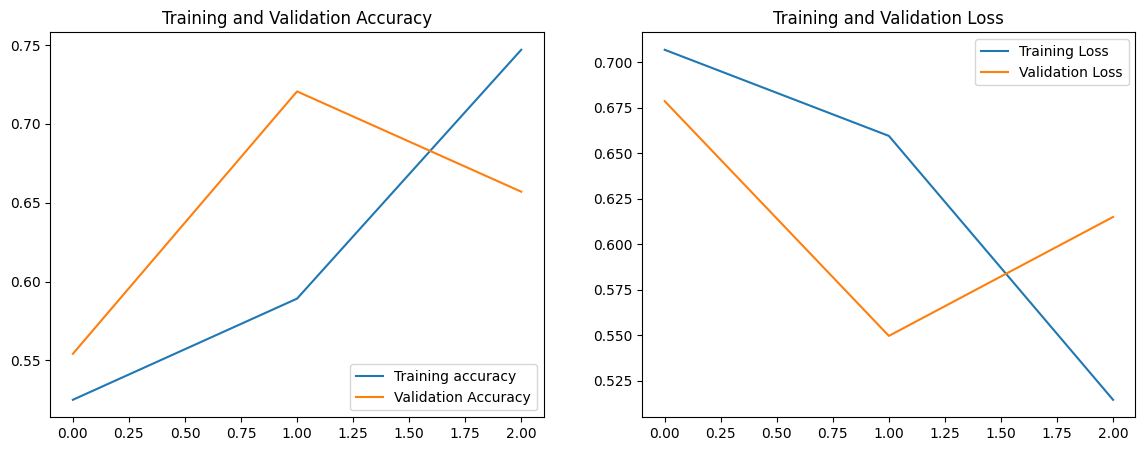

: 

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig('./foo.png')
plt.show()